# Comparison of MERLIN despeckled patches statistics
Small notebook loading, plotting and comparing statistics of diverse patches to adapt the metrics computations at best.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import sys
from pathlib import Path
from typing import Any, Dict

# Add parent directory to path to import from src
sys.path.append("..")
# Import SAR utilities
from src.utils.constants import amp_max, amp_min
from src.utils.sar_utils import (
    load_cosar,
    symmetrize,
)

# Hyperparameters
SHORT_IMAGE_NAME = "Hamburg"
CROP_COORDINATES = (11000, 8500)  # Hamburg: ncolumns=14686 nlines=32901
PATCH_SIZE = (1024, 1024)

# Paths
COSFILES_DIR = Path("../data/TSX_cos_files")
PROCESSED_DIR = Path("../data/processed_hdf5")
DENOISED_DIR = Path("../data/visualization")


def compute_statistics(data):
    return {
        "min": np.min(data),
        "p1": np.percentile(data, 1),
        "p10": np.percentile(data, 10),
        "mean": np.mean(data),
        "median": np.median(data),
        "std": np.std(data),
        "p90": np.percentile(data, 90),
        "p99": np.percentile(data, 99),
        "max": np.max(data),
    }


def print_statistics(data, name):
    stats = compute_statistics(data)
    print(f"Statistics for {name}:")
    for key, value in stats.items():
        print(f" - {key}: {value:.4f}")
    print("\n")

In [ ]:
# Load and print statistics of data/visualization/raw_Hamburg_patch_[11000:12024;8500:9524].npy
raw_patch = np.load(DENOISED_DIR / "raw_Hamburg_patch_[11000:12024;8500:9524].npy")
print_statistics(raw_patch, "Raw Patch")

# Load and print statistics of data/visualization/tmp.npy
print("Compared to the original COSAR data...")
raw_Hamburg = load_cosar(
    COSFILES_DIR
    / "Hamburg_TDX1_SAR__SSC______SM_S_SRA_20180112T165337_20180112T165345_IMAGE_HH_SRA_strip_004.cos"
)
print_statistics(raw_Hamburg, "Raw Hamburg")

Statistics for Raw Patch:
 - min: -32767.0000
 - p1: -865.0000
 - p10: -190.0000
 - mean: 0.4314
 - median: 1.0000
 - std: 389.9583
 - p90: 192.0000
 - p99: 861.0000
 - max: 32767.0000




In [3]:
# Load and print statistics of data/visualization/noisy_Hamburg_patch_[11000:12024;8500:9524].npy
noisy_patch = np.load(DENOISED_DIR / "noisy_Hamburg_patch_[11000:12024;8500:9524].npy")
print_statistics(noisy_patch, "Noisy Patch")

Statistics for Noisy Patch:
 - min: -34514.8594
 - p1: -860.4476
 - p10: -190.0130
 - mean: 0.5699
 - median: 0.0756
 - std: 389.9581
 - p90: 191.9288
 - p99: 864.4220
 - max: 31827.1914


Statistics for Raw Hamburg:
 - min: -32767.0000
 - p1: -401.0000
 - p10: -164.0000
 - mean: 0.0114
 - median: 0.0000
 - std: 191.4302
 - p90: 165.0000
 - p99: 402.0000
 - max: 32767.0000




In [ ]:
# Crop raw Hamburg and save as .npy
raw_Hamburg_crop = raw_Hamburg[
    CROP_COORDINATES[0] : CROP_COORDINATES[0] + PATCH_SIZE[0],
    CROP_COORDINATES[1] : CROP_COORDINATES[1] + PATCH_SIZE[1],
    :,
]
np.save(
    DENOISED_DIR / "raw_Hamburg_patch_[11000:12024;8500:9524].npy", raw_Hamburg_crop
)

In [4]:
# Open and print statistics of data/visualization/raw_Hamburg_patch_[11000:12024;8500:9524].npy
raw_patch = np.load(DENOISED_DIR / "raw_Hamburg_patch_[11000:12024;8500:9524].npy")
print_statistics(raw_patch, "Raw Patch")

Statistics for Raw Patch:
 - min: -32767.0000
 - p1: -865.0000
 - p10: -190.0000
 - mean: 0.4314
 - median: 1.0000
 - std: 389.9583
 - p90: 192.0000
 - p99: 861.0000
 - max: 32767.0000




In [5]:
# Symmetrize
raw_patch = symmetrize(raw_patch)
print_statistics(raw_patch, "Raw Patch Symmetrized")

Statistics for Raw Patch Symmetrized:
 - min: -34514.8594
 - p1: -860.4476
 - p10: -190.0130
 - mean: 0.5699
 - median: 0.0756
 - std: 389.9581
 - p90: 191.9288
 - p99: 864.4220
 - max: 31827.1914




In [ ]:
# for npy files in DENOISED_DIR
for npy_file in DENOISED_DIR.glob("*.npy"):
    if "patch" not in npy_file.stem:  # Skip the uncropped image "Hamburg_denoised.npy"
        continue
    # Load the denoised data
    print(f"Loading {npy_file}...")
    MERLIN_patch = np.load(npy_file, allow_pickle=True).item()
    print(MERLIN_patch["noisy"].keys())
    print(MERLIN_patch["denoised"].keys())
    print(MERLIN_patch["denoised"]["from_real"].shape)

    # ----- check stats of noisy -----
    noisy_patch = MERLIN_patch["noisy"]["full"]
    # Print statistics
    print_statistics(noisy_patch, "noisy" + npy_file.stem)

    # ----- check stats of denoised -----
    denoised_patch = MERLIN_patch["denoised"]["full"]
    # Print statistics
    print_statistics(denoised_patch, "denoised" + npy_file.stem)

    # # Clip the patches to mean ± 3*std before plotting
    # noisy_mean, noisy_std = np.mean(noisy_patch), np.std(noisy_patch)
    # noisy_clip_min, noisy_clip_max = noisy_mean - 3 * noisy_std, noisy_mean + 3 * noisy_std
    # noisy_patch_clipped = np.clip(noisy_patch, noisy_clip_min, noisy_clip_max)
    # plt.figure(figsize=(10, 10))
    # plt.imshow(noisy_patch_clipped, cmap="gray")
    # plt.title(f"Noisy Data: {npy_file.stem}")
    # plt.colorbar()
    # plt.axis("off")
    # plt.show()

    # denoised_mean, denoised_std = np.mean(denoised_patch), np.std(denoised_patch)
    # denoised_clip_min, denoised_clip_max = denoised_mean - 3 * denoised_std, denoised_mean + 3 * denoised_std
    # denoised_patch_clipped = np.clip(denoised_patch, denoised_clip_min, denoised_clip_max)
    # plt.figure(figsize=(10, 10))
    # plt.imshow(denoised_patch_clipped, cmap="gray")
    # plt.title(f"Denoised Data: {npy_file.stem}")
    # plt.colorbar()
    # plt.axis("off")
    # plt.show()

Loading ../data/denoised/val_Hamburg_MERLIN_patch_[11000:12024;8500:9524].npy...
dict_keys(['full', 'real', 'imaginary'])
dict_keys(['full', 'from_real', 'from_imaginary'])
(1024, 1024)
Statistics for noisyval_Hamburg_MERLIN_patch_[11000:12024;8500:9524]:
 - min: 0.0000
 - p1: 13.3417
 - p10: 44.0454
 - mean: 240.6868
 - median: 134.6477
 - std: 496.1906
 - p90: 460.8877
 - p99: 1881.6235
 - max: 34735.6602


Statistics for denoisedval_Hamburg_MERLIN_patch_[11000:12024;8500:9524]:
 - min: 51.2236
 - p1: 73.1286
 - p10: 91.5233
 - mean: 285.6781
 - median: 184.4228
 - std: 438.9890
 - p90: 531.1157
 - p99: 1893.2826
 - max: 28352.6230




In [ ]:
cos_file = next(COSFILES_DIR.glob(f"{SHORT_IMAGE_NAME}_*.cos"))
print(f"Loading {cos_file}...")
# Load the COSAR data
image = load_cosar(cos_file)
if image is None:
    raise ValueError(f"Image {cos_file.stem} could not be loaded")

patch = image[
    CROP_COORDINATES[0] : CROP_COORDINATES[0] + PATCH_SIZE[0],
    CROP_COORDINATES[1] : CROP_COORDINATES[1] + PATCH_SIZE[1],
    :,
]
print(patch.shape)
print_statistics(patch, "original")

symmetrized_patch = symmetrize(patch)
print_statistics(symmetrized_patch, "symmetrized")

# Store symmetrized patch at tmp.npy
np.save("../data/visualization/tmp.npy", symmetrized_patch)

squared_patch = np.square(symmetrized_patch)
print_statistics(squared_patch, "squared")

normalized_patch = np.log(squared_patch + 1e-2) - 2 * amp_min / (
    2 * amp_max - 2 * amp_min
)
print_statistics(normalized_patch, "normalized")


Loading ../data/TSX_cos_files/Hamburg_TDX1_SAR__SSC______SM_S_SRA_20180112T165337_20180112T165345_IMAGE_HH_SRA_strip_004.cos...
(1024, 1024, 2)
Statistics for original:
 - min: -32767.0000
 - p1: -865.0000
 - p10: -190.0000
 - mean: 0.4314
 - median: 1.0000
 - std: 389.9583
 - p90: 192.0000
 - p99: 861.0000
 - max: 32767.0000


Statistics for symmetrized:
 - min: -34514.8594
 - p1: -860.4476
 - p10: -190.0130
 - mean: 0.5699
 - median: 0.0756
 - std: 389.9581
 - p90: 191.9288
 - p99: 864.4220
 - max: 31827.1914


Statistics for squared:
 - min: 0.0000
 - p1: 1.8074
 - p10: 181.4642
 - mean: 152067.5938
 - median: 6098.5244
 - std: 4011416.5000
 - p90: 97206.5781
 - p99: 1676868.2500
 - max: 1191275520.0000


Statistics for normalized:
 - min: 0.0000
 - p1: 0.3390
 - p10: 0.6390
 - mean: 0.8533
 - median: 0.8680
 - std: 0.1725
 - p90: 1.0484
 - p99: 1.2339
 - max: 1.6617




### How MERLIN computes its "noisy" "full" and other components
**noisy**:
- "full" `noisy_image = np.squeeze(np.sqrt(noisy_image_real_part ** 2 + noisy_image_imaginary_part ** 2))`
- "real" and "imaginary" are simply the original

**denoised** (without taking into account the patchification, padding, and re-concatenation):
1. Prepare `symmetrize(noisy_image_real_part)` and `symmetrize(noisy_image_imaginary_part)`
2. Normalize `(torch.log(torch.square(real_to_denoise)+1e-3)-2*m)/(2*(M-m))`
3. Forward pass
4. De-Normalize `np.exp((M - m) * (np.squeeze(image)).astype('float32') + m)`
5. Combine `np.sqrt(np.squeeze(0.5 * (np.square(denoised_image_real_part) + np.square(denoised_image_imaginary_part)))`

**Takeaways**:
- "full" are the amplitude images, I need to add `sqrt()`
- Because his global min `m` and max `M` are computed on amplitude, he normalizes by twice them. I should also do that?  

Text(0.5, 1.0, 'MERLIN denoised patch amplitude normalized')

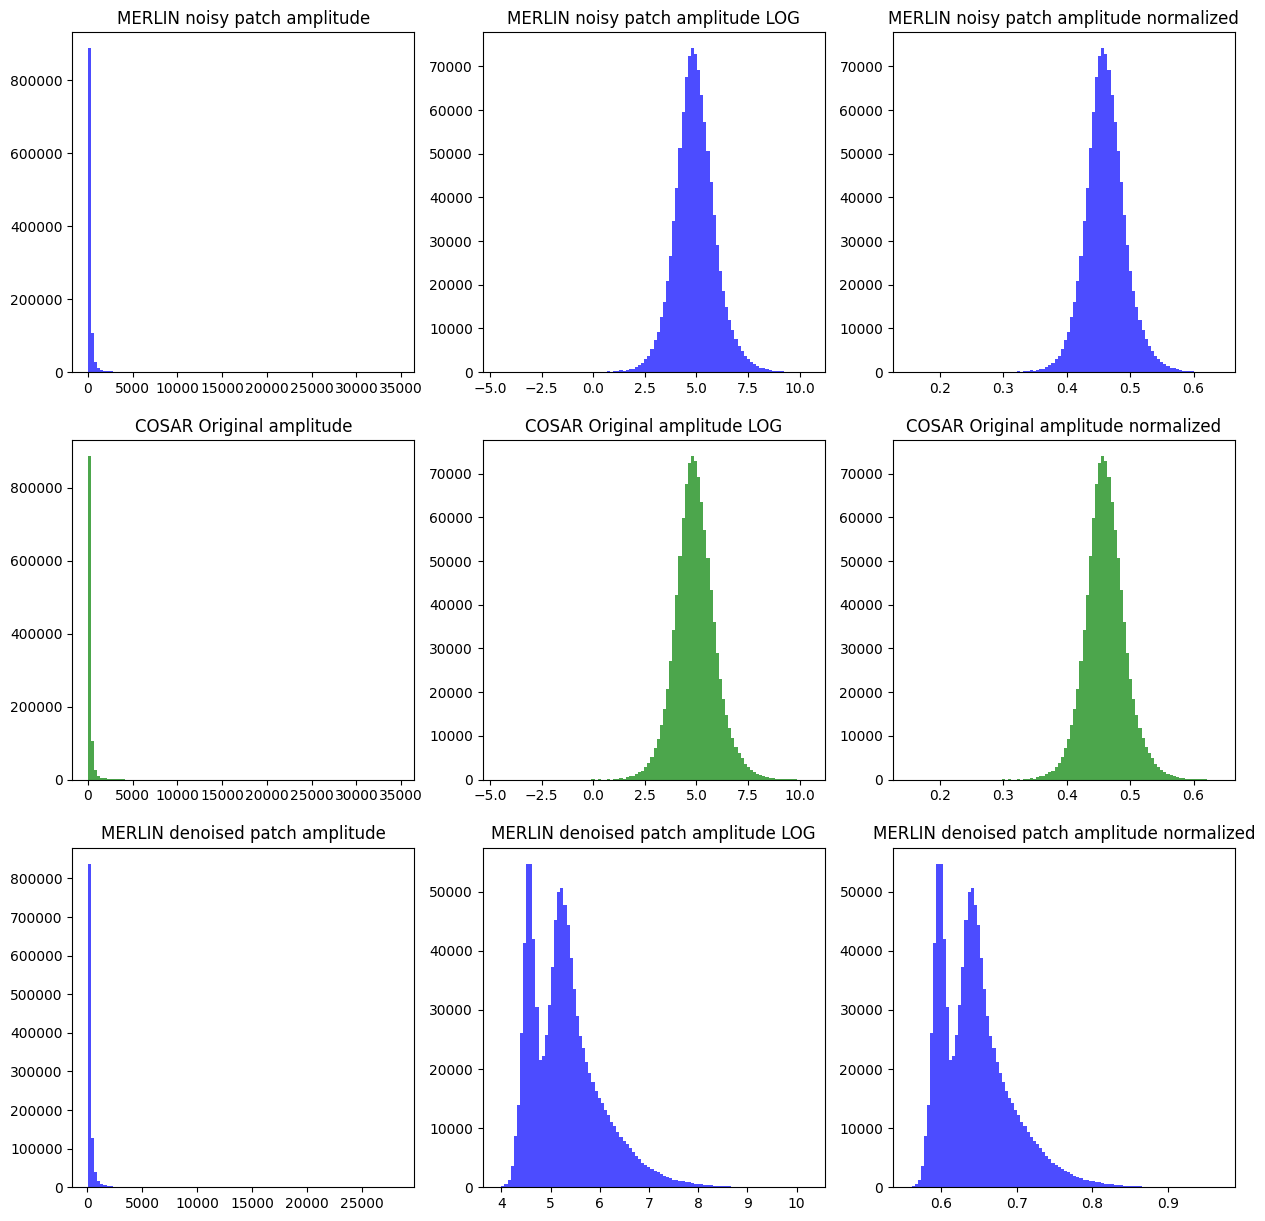

In [32]:
# Now let's plot histograms for both the MERLIN denoised data and the original COSAR data
# 2 rows (MERLIN / COSAR), 3 columns ("full", "from_real", "from_imaginary"), NOTE: for COSAR we need to compute full as the sum of the real and imaginary parts
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
# MERLIN data noisy
axes[0, 0].hist(noisy_patch.ravel(), bins=100, color="blue", alpha=0.7)
axes[0, 0].set_title("MERLIN noisy patch amplitude")
axes[0, 1].hist(np.log(noisy_patch + 1e-2).ravel(), bins=100, color="blue", alpha=0.7)
axes[0, 1].set_title("MERLIN noisy patch amplitude LOG")
axes[0, 2].hist(
    ((np.log(noisy_patch + 1e-2) - 2 * amp_min) / (2 * amp_max - 2 * amp_min)).ravel(),
    bins=100,
    color="blue",
    alpha=0.7,
)
axes[0, 2].set_title("MERLIN noisy patch amplitude normalized")
# COSAR data
amplitude = np.sqrt(squared_patch[:, :, 0] + squared_patch[:, :, 1])
axes[1, 0].hist(amplitude.ravel(), bins=100, color="green", alpha=0.7)
axes[1, 0].set_title("COSAR Original amplitude")
axes[1, 1].hist(np.log(amplitude + 1e-2).ravel(), bins=100, color="green", alpha=0.7)
axes[1, 1].set_title("COSAR Original amplitude LOG")
axes[1, 2].hist(
    ((np.log(amplitude + 1e-2) - 2 * amp_min) / (2 * amp_max - 2 * amp_min)).ravel(),
    bins=100,
    color="green",
    alpha=0.7,
)
axes[1, 2].set_title("COSAR Original amplitude normalized")
# MERLIN data denoised
axes[2, 0].hist(denoised_patch.ravel(), bins=100, color="blue", alpha=0.7)
axes[2, 0].set_title("MERLIN denoised patch amplitude")
axes[2, 1].hist(
    np.log(denoised_patch + 1e-2).ravel(), bins=100, color="blue", alpha=0.7
)
axes[2, 1].set_title("MERLIN denoised patch amplitude LOG")
axes[2, 2].hist(
    ((np.log(denoised_patch + 1e-2) - amp_min) / (amp_max - amp_min)).ravel(),
    bins=100,
    color="blue",
    alpha=0.7,
)
axes[2, 2].set_title("MERLIN denoised patch amplitude normalized")

In [27]:
# Load the patch
patch_np = np.load(patch_path)
print_statistics(patch_np, "Patch")
# plot histogram
plt.figure(figsize=(10, 5))
plt.hist(
    patch_np.flatten(),
    bins=100,
    range=(0, 1),
)

fig, axs = plt.subplots(2, 2, figsize=(10, 10))
im0 = axs[0, 0].imshow(convert_to_db(original_patch_np[:, :, 0] ** 2), cmap="gray")
im1 = axs[0, 1].imshow(convert_to_db(original_patch_np[:, :, 1] ** 2), cmap="gray")
im2 = axs[1, 0].imshow(patch_np[:, :, 0], cmap="gray", vmin=0, vmax=1)
im3 = axs[1, 1].imshow(patch_np[:, :, 1], cmap="gray", vmin=0, vmax=1)
axs[0, 0].set_title("Original Patch - Real^2 [dB]")
axs[0, 1].set_title("Original Patch - Imaginary^2 [dB]")
axs[1, 0].set_title("Processed Patch - Real")
axs[1, 1].set_title("Processed Patch - Imaginary")
# Add colorbars
fig.colorbar(im0, ax=axs[0, 0], fraction=0.046, pad=0.04)
fig.colorbar(im1, ax=axs[0, 1], fraction=0.046, pad=0.04)
fig.colorbar(im2, ax=axs[1, 0], fraction=0.046, pad=0.04)
fig.colorbar(im3, ax=axs[1, 1], fraction=0.046, pad=0.04)
# turn off axis
for ax in axs.flat:
    ax.axis("off")

NameError: name 'patch_path' is not defined